In [23]:
import numpy as np
import pandas as pd
from datasets import load_dataset

from task6.utils.balance_dataset import augment_minority_classes
from task6.utils.prepare_data import prepare_data

In [24]:
dataset = load_dataset("google-research-datasets/go_emotions")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [25]:
df = pd.DataFrame(dataset["train"])
df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [26]:
df, emotions = prepare_data(df, "text", "labels")
print(emotions)
df.head()

Detected dataset type: goemotions
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed
['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']


,text,id,ekman_emotion,tokenized_text,lemmatized_text
0,My favourite food is anything I didn't have to...,eebbqej,6,"[my, favourite, food, is, anything, i, did, n'...","[my, favourite, food, be, anything, I, do, not..."
1,"Now if he does off himself, everyone will thin...",ed00q6i,6,"[now, if, he, does, off, himself, ,, everyone,...","[now, if, he, do, off, himself, ,, everyone, w..."
2,WHY THE FUCK IS BAYLESS ISOING,eezlygj,0,"[why, the, fuck, is, bayless, isoing]","[why, the, fuck, be, bayless, isoe]"
3,To make her feel threatened,ed7ypvh,2,"[to, make, her, feel, threatened]","[to, make, she, feel, threaten]"
4,Dirty Southern Wankers,ed0bdzj,0,"[dirty, southern, wankers]","[dirty, southern, wanker]"


In [27]:
df_test = pd.read_csv("../../data/transcript_spell_checked.csv")
df_test, emotions_test = prepare_data(df_test, "Translation", "emotion_final")

Detected dataset type: transcript
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed


In [28]:
df_test.head()

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity,sentence_length,Language,predicted_emotion,Sentence_corrected,ekman_emotion,tokenized_text,lemmatized_text
0,00:00:00,00:00:07,Program zawiera tresci nieodpowiednie dla widz...,The program contains content inappropriate for...,warning,fear,mild,14,formal,disgust,Program zawiera treści nieodpowiednie dla widz...,1,"[the, program, contains, content, inappropriat...","[the, program, contain, content, inappropriate..."
1,00:00:07,00:00:09,Ogladasz na wlasna odpowiedzialnosc.,You watch at your own risk.,caution,fear,mild,4,informal,fear,oglądasz na własną odpowiedzialność.,2,"[you, watch, at, your, own, risk, .]","[you, watch, at, your, own, risk, .]"
2,00:00:10,00:00:13,Jedziemy do Piekowa!,We're going to Pięków!,excitement,happiness,moderate,3,informal,happiness,Jedziemy do piękowa!,3,"[we, 're, going, to, pięków, !]","[we, be, go, to, pięków, !]"
3,00:00:14,00:00:17,"Krakowiacek jeden, a okolicow siedem.","One Krakowiacek, and seven surroundings.",pride,happiness,mild,5,informal,neutral,"Krakowiacek jeden, a okolic siedem.",3,"[one, krakowiacek, ,, and, seven, surroundings...","[one, krakowiacek, ,, and, seven, surrounding, .]"
4,00:00:19,00:00:22,"Tak go dzgnalem w ta tarcze i widzialem, ze si...",So I stabbed him in that shield and I saw that...,irritation,anger,moderate,11,informal,anger,"tak go dźgnąłem w tą tarczę i widziałem, że si...",0,"[so, i, stabbed, him, in, that, shield, and, i...","[so, I, stab, he, in, that, shield, and, I, se..."


In [29]:
target_samples = 2500

classes_to_augment = df["ekman_emotion"].value_counts()[df["ekman_emotion"].value_counts() < target_samples].index.tolist()
print(f"Classes to augment: {classes_to_augment}")

Classes to augment: [2, 1]


In [30]:
df_augmented = augment_minority_classes(df, target_samples=target_samples, classes_to_augment=classes_to_augment)
df_augmented = pd.concat([df, df_augmented]).reset_index(drop=True)
print(df_augmented["ekman_emotion"].value_counts())
print(f"Original size: {len(df)}, Augmented size: {len(df_augmented)}")
df = df_augmented

Augmenting emotion 2: 691 → 2500
Augmenting emotion 1: 638 → 2500
Augmented Sample 1: this be extremely dangerous live . and would completely marginalize anyone without a chip . make it an absolute necessity for everyone to have informationtechnology a chip .
Augmented Sample 2: it pardner ’ hard when you have kid with the partner .
Augmented Sample 3: I be picture of needle and baby so that be not a phobic I want to see .
ekman_emotion
3    16920
6    12823
0     5579
5     4160
4     2599
2     2500
1     2500
Name: count, dtype: int64
Original size: 43410, Augmented size: 47081


In [31]:
df["lemmatized_text"] = df["lemmatized_text"].apply(lambda tokens: " ".join(tokens))
df_test["lemmatized_text"] = df_test["lemmatized_text"].apply(lambda tokens: " ".join(tokens))


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_word = TfidfVectorizer(max_features=40000, ngram_range=(1, 2))
tfidf_word = vectorizer_word.fit_transform(df["lemmatized_text"])
tfidf_word_test = vectorizer_word.transform(df_test["lemmatized_text"])

vectorizer_char = TfidfVectorizer(max_features=10000, ngram_range=(3, 5), analyzer='char')
tfidf_char = vectorizer_char.fit_transform(df["lemmatized_text"])
tfidf_char_test = vectorizer_char.transform(df_test["lemmatized_text"])

from scipy.sparse import hstack
X_train = hstack([tfidf_word, tfidf_char])
X_test = hstack([tfidf_word_test, tfidf_char_test])


In [33]:
# calculate number of tokens, ratio of unique tokens to total tokens, average word length
df["num_tokens"] = df["lemmatized_text"].apply(lambda x: len(x.split()))
df["unique_token_ratio"] = df["lemmatized_text"].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)
df["avg_word_length"] = df["lemmatized_text"].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)
df_test["num_tokens"] = df_test["lemmatized_text"].apply(lambda x: len(x.split()))
df_test["unique_token_ratio"] = df_test["lemmatized_text"].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)
df_test["avg_word_length"] = df_test["lemmatized_text"].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)

In [34]:
# calculate punctuation count
import string
df["punctuation_count"] = df["lemmatized_text"].apply(lambda x: sum([1 for char in x if char in string.punctuation]))
df_test["punctuation_count"] = df_test["lemmatized_text"].apply(lambda x: sum([1 for char in x if char in string.punctuation]))

In [35]:
# Negation feature: binary if any negation word in window of previous 3 tokens
negation_words = set(["not", "no", "never", "n't", "none", "nobody", "nothing", "neither", "nowhere", "hardly", "scarcely", "barely", "doesn't", "isn't", "wasn't", "shouldn't", "wouldn't", "couldn't", "won't", "can't", "don't"])
def negation_feature(text):
    tokens = text.split()
    for i, token in enumerate(tokens):
        if token in negation_words:
            return 1
        if i >= 3:
            break
    return 0
df["negation"] = df["lemmatized_text"].apply(negation_feature)
df_test["negation"] = df_test["lemmatized_text"].apply(negation_feature)

In [36]:
df.head()

,text,id,ekman_emotion,tokenized_text,lemmatized_text,num_tokens,unique_token_ratio,avg_word_length,punctuation_count,negation
0,My favourite food is anything I didn't have to...,eebbqej,6,"[my, favourite, food, is, anything, i, did, n'...",my favourite food be anything I do not have to...,13,1.000000,3.692308,1,0
1,"Now if he does off himself, everyone will thin...",ed00q6i,6,"[now, if, he, does, off, himself, ,, everyone,...","now if he do off himself , everyone will think...",22,0.954545,3.909091,1,0
2,WHY THE FUCK IS BAYLESS ISOING,eezlygj,0,"[why, the, fuck, is, bayless, isoing]",why the fuck be bayless isoe,6,1.000000,3.833333,0,0
3,To make her feel threatened,ed7ypvh,2,"[to, make, her, feel, threatened]",to make she feel threaten,5,1.000000,4.200000,0,0
4,Dirty Southern Wankers,ed0bdzj,0,"[dirty, southern, wankers]",dirty southern wanker,3,1.000000,6.333333,0,0


In [37]:
# combine all features into X_train and X_test
from scipy.sparse import csr_matrix
additional_features = ["num_tokens", "unique_token_ratio", "avg_word_length", "punctuation_count", "negation"]
X_train_additional = csr_matrix(df[additional_features].values)
X_test_additional = csr_matrix(df_test[additional_features].values)
X_train = hstack([X_train, X_train_additional])
X_test = hstack([X_test, X_test_additional])

In [38]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7711280 stored elements and shape (47081, 50005)>

In [39]:
y_train = df["ekman_emotion"]
y_test = df_test["ekman_emotion"]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (47081, 50005), y_train shape: (47081,)
X_test shape: (914, 50005), y_test shape: (914,)


In [40]:
n_samples, n_features = X_train.shape
dual_choice = False if n_samples > n_features else False

In [41]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV

In [42]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0],
    "max_iter": [5000, 10000, 15000, 20000, 25000],
    "class_weight": [None, "balanced"],
    "loss": ["hinge", "squared_hinge"],
    "penalty": ["l2"]  # L1 penalty often causes issues with LinearSVC
}

randomized_search = RandomizedSearchCV(
    LinearSVC(random_state=42, dual=dual_choice),
    param_grid,
    cv=3,
    n_jobs=12,
    verbose=2,
    n_iter=50,
    scoring='f1_macro',
    random_state=42,
    return_train_score=True
)

print("Starting randomized search (50 iterations)...")
randomized_search.fit(X_train, y_train)

print("\n" + "="*50)
print("RANDOMIZED SEARCH RESULTS")
print("="*50)
print(f"Best parameters: {randomized_search.best_params_}")
print(f"Best CV score: {randomized_search.best_score_:.4f}")
print(f"Best estimator: {randomized_search.best_estimator_}")

Starting randomized search (50 iterations)...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
51 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
51 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Pr


RANDOMIZED SEARCH RESULTS
Best parameters: {'penalty': 'l2', 'max_iter': 25000, 'loss': 'squared_hinge', 'class_weight': None, 'C': 0.5}
Best CV score: 0.6537
Best estimator: LinearSVC(C=0.5, dual=False, max_iter=25000, random_state=42)


In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
param_grid = {
    'C': np.arange(0.1, 0.8, 0.05).tolist(),
    'max_iter': [25000, 30000],
    'class_weight': ['balanced', None],
    'loss': ['squared_hinge'],
    'penalty': ['l2']
}
grid_search = GridSearchCV(
    LinearSVC(random_state=42, dual=dual_choice),
    param_grid,
    cv=3,
    n_jobs=12,
    verbose=2,
    scoring='f1_macro',
    return_train_score=True
)
print("Starting grid search...")
grid_search.fit(X_train, y_train)
print("\n" + "="*50)
print("GRID SEARCH RESULTS")
print("="*50)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")
print(f"Best estimator: {grid_search.best_estimator_}")

Starting grid search...
Fitting 3 folds for each of 56 candidates, totalling 168 fits

GRID SEARCH RESULTS
Best parameters: {'C': 0.20000000000000004, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 25000, 'penalty': 'l2'}
Best CV score: 0.6562
Best estimator: LinearSVC(C=0.20000000000000004, class_weight='balanced', dual=False,
          max_iter=25000, random_state=42)


In [45]:
best_params = grid_search.best_params_
svm_model = LinearSVC(**best_params, random_state=42, dual=dual_choice)
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,False
,tol,0.0001
,C,0.20000000000000004
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [46]:
from sklearn.metrics import classification_report
y_pred = svm_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=emotions_test, zero_division=0, digits=3))

Classification Report:
              precision    recall  f1-score   support

       anger      0.533     0.540     0.536       150
     disgust      0.143     0.023     0.039        44
        fear      0.700     0.171     0.275        41
         joy      0.723     0.418     0.530       225
     sadness      0.536     0.130     0.210       115
    surprise      0.333     0.383     0.356        81
     neutral      0.387     0.740     0.508       258

    accuracy                          0.460       914
   macro avg      0.479     0.344     0.351       914
weighted avg      0.510     0.460     0.434       914



In [47]:
# print random misclassified examples with emotion labels
import random
misclassified_indices = np.where(y_test != y_pred)[0]
random_indices = random.sample(list(misclassified_indices), min(5, len(misclassified_indices)))
for idx in random_indices:
    print(f"Text: {df_test.iloc[idx]['lemmatized_text']}")
    print(f"True label (name): {emotions_test[y_test.iloc[idx]]}, Predicted label (name): {emotions_test[y_pred[idx]]}")
    print("-"*50)

Text: it be hard for they to understand what the job be about .
True label (name): sadness, Predicted label (name): neutral
--------------------------------------------------
Text: apparently trypson start call I name or insult I or something ,
True label (name): anger, Predicted label (name): neutral
--------------------------------------------------
Text: no , I think we manage .
True label (name): joy, Predicted label (name): anger
--------------------------------------------------
Text: the beginning be difficult .
True label (name): sadness, Predicted label (name): neutral
--------------------------------------------------
Text: aha .
True label (name): neutral, Predicted label (name): joy
--------------------------------------------------


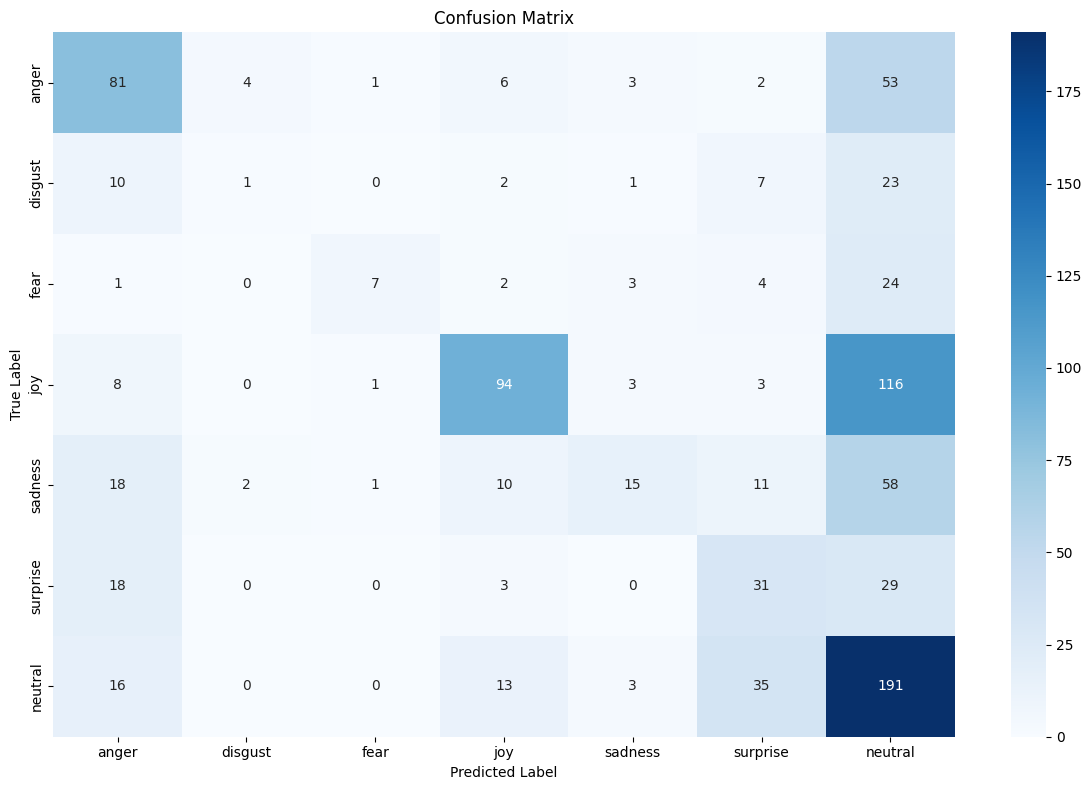

Classification Report:
              precision    recall  f1-score   support

       anger       0.53      0.54      0.54       150
     disgust       0.14      0.02      0.04        44
        fear       0.70      0.17      0.27        41
         joy       0.72      0.42      0.53       225
     sadness       0.54      0.13      0.21       115
    surprise       0.33      0.38      0.36        81
     neutral       0.39      0.74      0.51       258

    accuracy                           0.46       914
   macro avg       0.48      0.34      0.35       914
weighted avg       0.51      0.46      0.43       914


Top 5 Error Patterns: (true → predicted)
------------------------------
joy → neutral: 116 (23.5% of errors)
sadness → neutral: 58 (11.7% of errors)
anger → neutral: 53 (10.7% of errors)
neutral → surprise: 35 (7.1% of errors)
surprise → neutral: 29 (5.9% of errors)

Per-Class Performance:
------------------------------
anger        - P: 0.533, R: 0.540, F1: 0.536, Support: 15

In [48]:
from task6.utils.error_analysis import analyze_classification_errors

results = analyze_classification_errors(
    y_true=y_test,
    y_pred=y_pred,
    class_names=emotions_test,
    sample_texts=df_test["lemmatized_text"],
    model=svm_model,
    X_test=X_test,
    top_k_errors=5
)